## Step 1: Import Required Libraries

This section imports all essential libraries used for file handling, numerical operations, unit conversion, FITS file reading, and interaction with CASA data cubes.

Note: Most CASA functionalities (e.g., `casatasks`, `casatools`) are pre-installed in the `casa_env` environment used to run this notebook.

In [115]:
# File Access
from glob import glob
import pandas as pd
# Numerical tasks
from astropy import constants as const
from astropy import units as u
# Plot Generation
from astropy.io import fits
# CASA
from casatools import image

## Step 2: Define Source and Directory Paths

Set up basic parameters such as source name, distance, target molecular line, and rest frequency. 

In [116]:
source = '04166+2706'
target = '04166+2706' # In the case when the source name is slightly different for example, sourceAB, but we treat them as sourceA and sourceB
dist_pc = 140
line = 'C18O'
if line == '13CO':
    restfreq = 330.5879653#GHz
if line == 'C18O':
    restfreq = 329.3305525#GHz
line_dir = f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/{source}/line/ALMA/{line}'
mask_dir = f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/{source}/keplerian'

## Step 3: Extract Disk Parameters from Continuum Results

Load physical and geometric properties of the disk from the continuum measurement file.  
This includes the disk radius (arcsec), position angle, inclination, and sky coordinates (RA/Dec in sexagesimal format).

In [117]:
# Get disk information from the continuum results
taurus_ALMA = np.genfromtxt(f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/continuum_data/ALMA_data/alma_continuum_measurements.dat', delimiter=",", names=True, dtype=None, encoding="utf-8")#taurus 345 GHz
row = taurus_ALMA[taurus_ALMA['source'] == target][0]
dust_r = row[8]/140 #arcsec
pa = row[12]
i = row[10]
ra_deg = row[1] # deg
dec_deg = row [2] #deg
from astropy.coordinates import SkyCoord
import astropy.units as u
coord = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame='icrs')
ra_center = coord.ra.to_string(unit=u.hour, sep=':', pad=True, precision=3)
dec_center = coord.dec.to_string(sep=':', pad=True, precision=3, alwayssign=True).split(':')
dec_center = f"{dec_center[0]}.{dec_center[1]}.{dec_center[2]}"
print(f"Disk Center (RA, Dec): {ra_center}  {dec_center}")
print(f"Dust Radius (arcsec): {dust_r:.4f}")
print(f"Position Angle (degrees): {pa:.2f}")
print(f"Inclination (degrees): {i:.2f}")

Disk Center (RA, Dec): 04:19:42.507  +27.13.35.792
Dust Radius (arcsec): 0.0713
Position Angle (degrees): 121.11
Inclination (degrees): 39.10


## Step 4: Estimate Systemic Velocity

Calculate the systemic velocity (vlsr) of the disk using the median value from the moment-1 map within the dust continuum region.

In [118]:
# Calculate systemic velocity from moment1 map
def get_systemic_velocity(moment1, region):
    moment1_stats = imstat(imagename=moment1, region = region)
    avg_velocity = moment1_stats['median'][0] # km/s
    return avg_velocity * 1e3 #m/s
moment1 = f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/{source}/line/ALMA/C18O/{source}_{line}_moment1_clipped3.image'#f'{line_dir}/{source}_13CO_moment1.fits'
dust_region = f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/{source}/continuum/ALMA/clean/{source}_ALMA_region'
vlsr = get_systemic_velocity(moment1, dust_region)
print(f"Systemic Velocity (vlsr): {vlsr:.2f} m/s")

Systemic Velocity (vlsr): 6954.88 m/s


## Step 5: Identify Systemic Velocity Channel

Given the systemic velocity and rest frequency, compute the corresponding velocity axis and return the channel index that best matches the systemic velocity.

In [119]:
# Get velocity channel
from astropy.constants import c

def get_vlsr_chan(cube_image, v_sys, restfreq):
    """
    Returns the channel index of the systemic velocity.
    """
    ia = image()
    ia.open(cube_image)
    csys = ia.coordsys()
    shape = ia.shape()
    n_chan = shape[3]
    freq_axis = []

    for chan in range(n_chan):
        world = csys.toworld([0, 0, 0, chan], 'n')['numeric']
        freq_hz = world[3]
        freq_axis.append(freq_hz)

    ia.close()
    freq_axis = np.array(freq_axis) # Hz
    
    restfreq_Hz = restfreq * 1e9
    velocity_axis = (c.value * (1 - freq_axis / restfreq_Hz)) / 1e3 # km/s
    v_sys = v_sys/1e3 # km/s # Keep an eye for a negative velocity
    vlsr_chan = int(np.argmin(np.abs(velocity_axis - v_sys)))
    return vlsr_chan
mid_chan = get_vlsr_chan(f'{line_dir}/{source}_{line}_clean.image', vlsr, restfreq)
print('Systemic Velocity channel :', mid_chan)

Systemic Velocity channel : 108


## Step 6: Determine Redshifted Side of Disk

Check whether the provided position angle points toward the redshifted side of the disk.  
If not, add 180° to the PA because keplerian_mask.py code defines pa with the redshifted side of the major axis. This uses pixel sampling along the PA direction from the moment-1 map to compare redshifted vs blueshifted emission.

In [125]:
# Check if 180 needs to be added in the case of pa is blueshifted
import math
def check_pa_redshifted(moment1, pa, offset=10):
    moment0 = f'{line_dir}/{source}_{line}_moment0.image'
    cont_region = f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/{source}/continuum/ALMA/clean/{source}_ALMA_region'
    moment0_fit = imfit(imagename=moment0, region = cont_region)
    cx = moment0_fit["results"]["component0"]["pixelcoords"][0]
    cy = moment0_fit["results"]["component0"]["pixelcoords"][1]

    ia = image()
    ia.open(moment1)
    data = ia.getchunk()
    ia.close()

    data = np.squeeze(data) 
    
    
    pa_rad = math.radians(pa)
    dx = math.cos(pa_rad)
    dy = math.sin(pa_rad)

    x1 = int(round(cx - offset * dx)) # blue shifted
    y1 = int(round(cy - offset * dy))
    x2 = int(round(cx + offset * dx))
    y2 = int(round(cy + offset * dy)) # redshifted

    v1 = data[y1, x1]
    v2 = data[y2, x2]

    if v1 > v2:
        print("Redshifted side is along the PA direction.")
        return pa
    else:
        print("Blueshifted side is along the PA direction.")
        return pa + 180
        
moment1 = f'{line_dir}/{source}_{line}_moment1.image' #f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/{source}/line/ALMA/13CO/{source}_13CO_moment1.fits'#f'{line_dir}/{source}_{line}_moment1.image'
pa = pa  # in deg
updated_pa = check_pa_redshifted(moment1, pa)
print('updated pa: ', updated_pa)

2025-04-30 21:45:35	WARN	imfit::ImageFitter::_fitLoop	Fit failed to converge because of exception: Exception: Ellipsoid lies completely outside the lattice.
2025-04-30 21:45:35	WARN	imfit::ImageFitter::_fitLoop+	... thrown by casacore::Slicer casacore::LCEllipsoid::makeBox(const casacore::Vector<float>&, const casacore::IPosition&) at File: /source/casa6/casatools/casacore/lattices/LRegions/LCEllipsoid.cc, line: 290


KeyError: 'component0'

## Step 7: Save Key Disk Parameters to File

Print and write to file the source name, disk center, radius, inclination, corrected position angle, and systemic velocity.  
These parameters are later used in Keplerian mask generation.

In [104]:
print(f'Source: {source}')
print(f'Disk Center: {ra_center} {dec_center}')
print(f'Dust Radius (arcsec): {dust_r}')
print(f'Inclination (degrees): {i}')
print(f'Updated Position Angle (degrees): {updated_pa}')
print(f'Systemic Velocity (m/s): {vlsr}')

file = f'{line_dir}/{source}_mask_param.txt'
with open(file, "w") as f:  # Use "w" to overwrite the file
    f.write(f"Source: {source}\n")
    f.write(f"Disk Center: {ra_center} {dec_center}\n")
    f.write(f"Dust Radius (arcsec): {dust_r}\n")
    f.write(f"Inclination (degrees): {i}\n")
    f.write(f"Updated Position Angle (degrees): {updated_pa}\n")
    f.write(f"Systemic Velocity (m/s): {vlsr}\n")

Source: 04158+2805
Disk Center: 04:18:58.055 +28.12.22.889
Dust Radius (arcsec): 3.3580714285714284
Inclination (degrees): 70.09
Updated Position Angle (degrees): 273.19
Systemic Velocity (m/s): 7000.0


## Generate Keplerian Mask Using Teague's `make_mask.py`

This step generates a Keplerian mask using a publicly available CASA-based script by Richard Teague  
([GitHub](https://github.com/richteague/keplerian_mask); rteague@mit.edu, 2020).  
The goal is to isolate disk emission from contaminating envelope emission in young, embedded disks.

Young Class 0/I disks often show extended low-velocity envelope emission, especially near the systemic velocity.  
To mitigate this, we use the Keplerian mask to select only those regions of the data cube (x, y, v) that are kinematically consistent with disk rotation around a central star.

The mask is constructed using:
- Source geometry: inclination, position angle (PA), systemic velocity (`vlsr`)
- A **trial stellar mass (`mstar`)**
- A **projected Keplerian velocity profile**
- A **local linewidth profile** (broader in the inner disk, narrower in the outer disk)
- An **emission height model** via `z/r = 0.3`, to account for the vertically extended CO emission in flared disks
- A **target resolution** (`target_res = 0.3 arcsec`) to match the angular resolution of the data cube

We define the mask radius as `r_max = 1.5 × dust radius`, since gas emission often extends beyond the compact millimeter dust emission.

### Mass Grid Search and Refinement

We first create a series of masks for trial stellar masses in the range **0.0–2.0 M☉** (in steps of 0.05 M☉).  
Each mask is evaluated using an automated function that checks for:
- Whether emission within the mask is real (i.e., >3× RMS)
- Whether significant emission exists outside the mask, suggesting underestimation of mass

The **best-fit stellar mass** is selected based on these criteria.  
We then generate a **finer mass grid around this best-fit value** to estimate an uncertainty range.

### Radial Masking Step

Using the best-fit `mstar`, we also generate a series of Keplerian masks by varying the outer mask radius from  
**1× to 3× the dust radius** (in 15 steps). This is motivated by the fact that gas emission typically extends farther than the millimeter dust disk.

Currently, identifying a single "best" gas radius is challenging due to the complexity of low-SNR emission and the absence of a well-defined evaluation metric.  
If a more robust method is not developed, we plan to adopt a simple statistical approach:  
**take the average and standard deviation** of the derived gas radii across all masks (at fixed stellar mass) and report that as the gas disk radius and its uncertainty.

In [105]:
# Import keplerian_mask.py
code_dir = f'/lustre/cv/users/psheehan/ForNoshin/Taurus_Young_Disks/keplerian_mask'
os.chdir(code_dir)
%run keplerian_mask.py

Successfully imported `make_mask`.


**Recenter Keplerian Mask to Disk Center**

After generating the Keplerian mask, we recenter it to the source’s actual RA/Dec position.  
This is important because in many observations, the source is **not exactly at the center of the image**.

This function updates the phase center of the mask image to match the measured source position,  
then regrids the image to ensure CASA applies the new coordinate system properly.

The mask is now correctly aligned with the disk center.

In [32]:
# Recenter mask to the ra and dec center of the disk
def recenter_mask(moment0, mask_image, recentered_mask_image):
    # Open the image and modify its coordinate system
    ia = image()
    ia.open(mask_image)
    csys = ia.coordsys()
    csys.setreferencevalue([ra_center, dec_center], type="direction")
    ia.setcoordsys(csys.torecord())
        
    # Regrid the image to ensure the new phase center is applied
    ia.done()  
    imregrid(
        imagename=mask_image,
        template=moment0, 
        output=recentered_mask_image,
        overwrite=True
        )

In [36]:
def generate_mask(line_image, i, pa, mstar, dist_pc, vlsr, dust_r, mode, r_factor = None, verbose = False):
    """
    Generate and recenter a Keplerian mask.

    Parameters:
    - line_image: str, path to the image cube
    - i: float, disk inclination in degrees
    - pa: float, position angle in degrees
    - mstar: float, stellar mass in solar masses
    - dist_pc: float, source distance in parsecs
    - vlsr: float, systemic velocity in m/s
    - dust_r: float, dust radius in arcsec
    - mode: str, either 'm' (vary mass) or 'r' (vary radius)
    """
    if mode == 'm':
        r_max = 1.5 * dust_r
        label = f"m{mstar:.3f}_1.5dust_r_0.3zr"

    elif mode == 'r':
        if r_factor is None:
            raise ValueError("You must specify `r_factor` when mode='r'.")
        r_max = r_factor * dust_r
        label = f"r{mstar:.2f}_{r_factor:.2f}dust_r_0.3zr"

    
    make_mask(
        image=line_image,
        inc=i,
        PA=pa,
        mstar=mstar,
        dist=dist_pc,
        vlsr=vlsr,
        r_min=0,
        r_max=r_max,
        zr=0.3,
        target_res=0.3
    )

    if verbose:
        print("\nCalling make_mask with the following parameters:")
        print(f"image       = {line_image}")
        print(f"inc         = {i}")
        print(f"PA          = {pa}")
        print(f"mstar       = {mstar}")
        print(f"dist        = {dist_pc}")
        print(f"vlsr        = {vlsr}")
        print(f"r_min       = 0")
        print(f"r_max       = {r_max} (factor = {r_max/dust_r:.2f})")
        print(f"target_res  = 0.3")

    moment0 = f'{line_dir}/{source}_{line}_moment0.image'
    recentered_mask = f'{mask_dir}/{label}.conv.mask.image'
    recenter_mask(moment0, f'{line_dir}/{source}_{line}_clean.mask.image', recentered_mask)
    os.system(f'rm -r {line_dir}/{source}_{line}_clean.mask.image')

## Step 8: Generate Keplerian Masks While Varying Stellar Mass

In this step, we create a series of Keplerian masks using a grid of trial stellar masses ranging from **0.00 to 2.00 M☉** in steps of **0.05 M☉**.  
This helps determine which stellar mass best matches the observed velocity structure of the disk.

Each mask is generated using the previously defined disk geometry and systemic velocity,  
and is then recentered to the true disk center.

In [37]:
# Define image path
line_image = f'{line_dir}/{source}_{line}_clean.image'

# Stellar mass grid: 0.00 to 2.00 M☉ in 0.05 steps
mstars = np.arange(0.00, 2.05, 0.05)

# Loop over mass and generate Keplerian masks
for m in mstars:
    print(f"Generating mask for mstar = {m:.2f} M☉")
    generate_mask(
        line_image=line_image,
        i=i,
        pa=updated_pa,
        mstar=m,
        dist_pc=dist_pc,
        vlsr=vlsr,
        dust_r=dust_r,
        mode='m'
    )

Generating mask for mstar = 0.00 M☉
# Estimated RMS of unmasked regions: 6.68 mJy/beam
# If there are strong sidelobes this may overestimate the RMS.
Generating mask for mstar = 0.05 M☉
# Estimated RMS of unmasked regions: 6.68 mJy/beam
# If there are strong sidelobes this may overestimate the RMS.
Generating mask for mstar = 0.10 M☉
# Estimated RMS of unmasked regions: 6.68 mJy/beam
# If there are strong sidelobes this may overestimate the RMS.
Generating mask for mstar = 0.15 M☉
# Estimated RMS of unmasked regions: 6.67 mJy/beam
# If there are strong sidelobes this may overestimate the RMS.
Generating mask for mstar = 0.20 M☉
# Estimated RMS of unmasked regions: 6.67 mJy/beam
# If there are strong sidelobes this may overestimate the RMS.
Generating mask for mstar = 0.25 M☉
# Estimated RMS of unmasked regions: 6.67 mJy/beam
# If there are strong sidelobes this may overestimate the RMS.
Generating mask for mstar = 0.30 M☉
# Estimated RMS of unmasked regions: 6.67 mJy/beam
# If there ar

## Step 9: Evaluate Keplerian Masks to Find Best-Fit Stellar Mass

Each mask generated in Step 8 is evaluated to determine whether it accurately matches the real disk emission  
without introducing significant noise or missing important emission.

The evaluation is based on the following criteria:
- **Contamination check:** No significant masked emission should be present in channels outside the ±5 km/s range around the systemic velocity.
- **Mask completeness check:** The mask must select at least some velocity channels with nonzero emission (i.e., the mask cannot be completely empty).
- **Emission strength check:** At least one of the first or last masked channels must show strong emission (peak > 3× RMS) to ensure real disk signal is captured at the mask edges.
- **Emission containment check:** There should be no strong emission (>3× RMS) immediately beyond the last masked channel to avoid masking missing extended disk emission.

If multiple stellar masses satisfy all these conditions,  
**the highest mass is selected** to account for the possibility that faint disk emission at higher velocities is hidden below the noise level.

We use a velocity window of **±5 km/s** centered on the systemic velocity.  
This range is motivated by Keplerian rotation speeds expected in young disks:
- Gas at 10 au around a 1 \(M_\odot\) star orbits at ~9.4 km/s.
- Gas at 50 au orbits at ~4.2 km/s.
  
Given our spatial resolution (~0.3 arcsec ≈ 40 au at 140 pc),  
we are mainly sensitive to gas at radii larger than 30–40 au, making ±5 km/s a reasonable and sufficient cutoff for capturing all resolvable disk emission without including unrelated noise or envelope contamination.

In [123]:
def find_best_mstar(line_image, mstars, mask_list, rms, mid_chan):
    """
    Evaluate all trial stellar masses and select the best-fitting one.
    Prefer the highest mass that passes all evaluation criteria.

    Parameters:
    - line_image: str, path to the line data cube
    - mask_list: list of str, list of mask file paths (must correspond to each trial mstar)
    - rms: float, RMS noise of the line image (in Jy/beam)
    - mid_chan: int, channel index corresponding to systemic velocity (vlsr)
    - mstars: array-like, list of trial stellar masses in Msun

    Returns:
    - best_mstar: float, the selected best-fit stellar mass, or None if none satisfied the criteria.
    """

    good_masses = []

    # Load line data once
    ia = image()
    ia.open(line_image)
    line_data = ia.getchunk()
    ia.close()

    low_chan = mid_chan - 20
    high_chan = mid_chan + 21
    
    for mstar, mask_image in zip(mstars, mask_list):
        ia.open(mask_image)
        mask_data = ia.getchunk()
        ia.close()

        binary_mask = np.where(mask_data > 0, 1, 0)

        # --- Condition 1: Check emission 5km/s before and after line ---
        pre_line_data = line_data[:, :, 0, :low_chan]
        pre_mask = binary_mask[:, :, 0, :low_chan]
        post_line_data = line_data[:, :, 0, high_chan:]
        post_mask = binary_mask[:, :, 0, high_chan:]

        if np.any(pre_line_data[pre_mask == 1] != 0) or np.any(post_line_data[post_mask == 1] != 0):
            print(f"Dropping Mass = {mstar:.3f} M_sun → Reason: Mask includes emission outside the ±5 km/s window.")
            continue

        # --- Condition 2: Check that mask covers any emission ---
        channel_sums = np.sum(binary_mask[:, :, 0, :], axis=(0, 1))
        nonzero_channels = np.where(channel_sums > 0)[0]
        if len(nonzero_channels) == 0:
            print(f"Dropping Mass = {mstar:.3f} M_sun → Reason: Mask does not include any channels with emission.")
            continue

        first_nonzero_chan = nonzero_channels[0]
        last_nonzero_chan = nonzero_channels[-1]

        # --- Condition 3: Check emission strength at first and last masked channels ---
        line_slice_first = line_data[:, :, 0, first_nonzero_chan] * binary_mask[:, :, 0, first_nonzero_chan]
        line_slice_last = line_data[:, :, 0, last_nonzero_chan] * binary_mask[:, :, 0, last_nonzero_chan]

        if np.nanmax(line_slice_first) < 3.0 * rms and np.nanmax(line_slice_last) < 3.0 * rms:
            print(f"Dropping Mass = {mstar:.3f} M_sun → Reason: Emission at both first and last masked channels is weaker than 3×RMS.")
            continue

        # --- Condition 4: Check no strong emission beyond the last masked channel ---
        after_last_chan = last_nonzero_chan + 1
        if after_last_chan < line_data.shape[-1]:
            line_after = line_data[:, :, 0, after_last_chan] * binary_mask[:, :, 0, last_nonzero_chan]
            if np.nanmax(line_after) > 3.0 * rms:
                print(f"Dropping Mass = {mstar:.3f} M_sun → Reason: Emission continues beyond the masked region (>3×RMS).")
                continue

        # If passed all conditions
        print(f"Accepted Mass = {mstar:.3f} M_sun")
        good_masses.append(mstar)

    # Select the maximum good mass
    if good_masses:
        best_mstar = max(good_masses)
        print(f"\nBest-fit stellar mass = {best_mstar:.3f} M_sun")
        return best_mstar
    else:
        print("\nNo stellar mass satisfied all evaluation criteria.")
        return None

In [124]:
# --- Load line image and RMS ---
line_image = f'{line_dir}/{source}_{line}_clean.image'
stats = imstat(imagename=line_image, chans=str(0))  # Calculate RMS for channel 0
rms = stats["rms"][0]
print(f"RMS: {rms:.3e}")

# --- Mid channel already known ---
mid_chan = get_vlsr_chan(f'{line_dir}/{source}_{line}_clean.image', vlsr, restfreq)

# --- Build list of mask files ---
mask_list = [os.path.join(mask_dir, f) for f in os.listdir(mask_dir)
             if f.startswith('m') and f.endswith('.conv.mask.image') and f.split("_")[1] == '1.5dust']

# --- Extract corresponding mstars ---
mstars = []
for mask in mask_list:
    mstar_str = (mask.split("/")[-1]).split("_")[0]  # e.g., "m0.750"
    mstar = float(mstar_str[1:])  # Remove "m" and convert to float
    mstars.append(mstar)

# --- Sort both lists by stellar mass ---
sorted_indices = np.argsort(mstars)
mstars = np.array(mstars)[sorted_indices]
mask_list = np.array(mask_list)[sorted_indices]

# --- Now evaluate all masks together ---
best_mstar = find_best_mstar(line_image, mstars, mask_list, rms, mid_chan)

RMS: 6.724e-03

No stellar mass satisfied all evaluation criteria.


## Step 10: Find Best-Fit Stellar Mass Using Penalized Chi²

In this step, we select the best-fit stellar mass by minimizing a penalized chi² cost.

- For each trial Keplerian mask (generated with a different stellar mass), we compute a reduced chi² by comparing the masked model to the observed line cube.
- To avoid favoring masks that artificially cover more pixels and lower the chi², a penalty term based on the number of masked voxels is added.
- The final cost is calculated as:

  Cost = normalized chi^2 + (range of chi^2) x normalized voxel count


- This ensures the penalty strength naturally matches the variation across the trial chi² values without manual tuning.
- The stellar mass corresponding to the lowest total cost is selected as the best-fit mass.

This approach balances goodness of fit with compactness of the mask, helping to avoid overfitting noise at high or low velocities.

In [108]:
def find_best_mstar_chi2(line_image, mask_list, rms):
    """
    Find the best-fit stellar mass by minimizing normalized chi² + penalty.

    Parameters:
    - line_image: str, path to the line data cube
    - mask_list: list of str, paths to mask images
    - rms: float, RMS noise

    Returns:
    - costs: final chi2 after scaling
    - mstar_vals: stella mass list
    - best_mstar: float, best-fit stellar mass (M_sun)
    """

    raw_chi2s = []
    voxel_counts = []
    mstar_vals = []

    # Load line data once
    ia = image()
    ia.open(line_image)
    line_data = ia.getchunk()
    ia.close()

    for mask_path in mask_list:
        mstar = (mask_path.split("/")[-1]).split("_")[0]
        mstar = float(mstar[1:])

        ia.open(mask_path)
        mask_data = ia.getchunk()
        ia.close()

        binary_mask = (mask_data > 0).astype(float)

        model_data = line_data * binary_mask

        residual = (line_data - model_data) / rms
        chi2 = np.nansum(residual ** 2)
        num_voxels = np.sum(binary_mask)

        raw_chi2s.append(chi2)
        voxel_counts.append(num_voxels)
        mstar_vals.append(mstar)

    raw_chi2s = np.array(raw_chi2s)
    voxel_counts = np.array(voxel_counts)
    mstar_vals = np.array(mstar_vals)

    # Normalize chi²
    max_chi2 = np.max(raw_chi2s)
    normalized_chi2s = raw_chi2s / max_chi2
    print(normalized_chi2s)

    # Normalize voxel counts
    normalized_voxels = voxel_counts / np.max(voxel_counts)
    print(normalized_voxels)

    # Estimate penalty scaling (beta)
    chi2_range = np.max(normalized_chi2s) - np.min(normalized_chi2s)
    print(chi2_range)
    voxel_range = np.max(normalized_voxels) - np.min(normalized_voxels)
    print(voxel_range)
    
    # Final cost
    costs = normalized_chi2s + chi2_range * normalized_voxels

    # Find best
    best_index = np.argmin(costs)
    best_mstar = mstar_vals[best_index]

    print(f"\nBest-fit mass: {best_mstar:.3f} M_sun (Cost = {costs[best_index]:.4f})")

    return costs, mstar_vals, best_mstar

rms: 0.006785818148914835
[0.98955512 0.99671503 0.99009583 0.98954513 0.98958321 0.98941398
 0.9894382  0.98942223 0.9894357  0.98941777 0.98966899 0.98953641
 0.99034926 1.         0.98951762 0.98939585 0.98946503 0.98942732
 0.98945951 0.98939976 0.9908459  0.98953933 0.99296997 0.98978567
 0.98951809 0.98949441 0.98947177 0.98943462 0.98950528 0.98941185
 0.98944902 0.989511   0.98990463 0.99461182 0.98955233 0.99174759
 0.98946188 0.98947134 0.9894984  0.98941171 0.9895363 ]
[0.98087781 0.47807975 0.63436975 0.72922784 0.70573917 0.91879345
 0.93987302 0.87959547 0.80772416 0.82122512 0.68767096 0.720796
 0.61881101 0.49875781 0.99156817 0.83101207 0.79547793 0.88762579
 0.94504254 0.92848001 0.60229868 0.96657382 0.53845768 0.66674195
 1.         0.7555773  0.95232001 0.89876785 0.7789656  0.83828954
 0.85670908 0.74207634 0.65068132 0.51351351 0.9738011  0.57098045
 0.86576828 0.84426209 0.7665688  0.90870536 0.95708801]
0.010604149905162563
0.5219202489397475

Best-fit mass: 0.

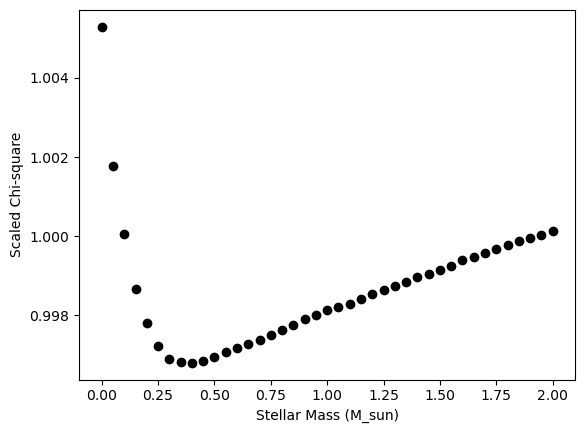

In [109]:
# Setup
line_image = f'{line_dir}/{source}_{line}_clean.image'

# Get RMS from channel 0
stats = imstat(imagename=line_image, chans=str(0))
rms = stats["rms"][0]
print(f"rms: {rms}")

# Get list of all generated masks
import os
mask_list = [
    os.path.join(mask_dir, f) for f in os.listdir(mask_dir)
    if f.startswith('m') and f.endswith('.conv.mask.image') and f.split("_")[1] == '1.5dust'
]

# Call the updated best mass finder
costs, mstars, best_mstar_chi2 = find_best_mstar_chi2(line_image, mask_list, rms)

plt.scatter(mstars, costs, marker='o', c = 'black')
plt.xlabel('Stellar Mass (M_sun)')
plt.ylabel('Scaled Chi-square')
plt.show()

## Step 11: Plot Channel Maps

In this step, we visualize the emission channels from the observed data cube.

- If a Keplerian mask is provided, channels with detected emission (nonzero mask) are automatically selected.
- If no mask is provided, channels within ±7 km/s of the systemic velocity are selected based on the mid-channel index.
- The observed cube is plotted as the background image.
- Mask contours can optionally be overlaid to highlight the Keplerian-selected regions.
- The number of subplots dynamically adjusts to fit the number of selected channels.
- Each subplot shows a zoomed-in view centered on the disk and labeled with its velocity.
- All channel maps are saved together into a single PNG figure.

This visualization allows us to verify how well the Keplerian mask (or velocity window) captures real disk emission across velocities.

In [111]:
import math
from casatools import image
def plot_channel_maps_auto(observed_cube, rest_freq, center_coords, mid_chan=None, mask_cube=None, zoom_factor=3.0, chan_width_kms=0.25):
    """
    Plot channel maps from the observed cube, optionally overlaying a Keplerian mask.

    If mask is provided: channels are selected based on detected emission.
    If no mask is provided: channels are selected based on ±57km/s from systemic velocity.
    
    Parameters
    ----------
    observed_cube : str
        Path to the observed spectral cube (.image).
    rest_freq : float
        Rest frequency of the observed line in GHz.
    center_coords : tuple of int
        (y, x) pixel coordinates of disk center.
    mid_chan : int, optional
        Mid channel index corresponding to vlsr. Required if mask is not provided.
    mask_cube : str or None
        Path to mask cube. If None, use simple ±7 km/s range.
    zoom_factor : float
        How much to zoom into disk center.
    chan_width_kms : float
        Channel width in km/s (default 0.25 km/s).
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from astropy.coordinates import SpectralCoord
    from astropy import units as u
    from astropy.io import fits
    from astropy.wcs import WCS

    im = image()
    # Load observed cube
    im.open(observed_cube)
    cube_data = im.getchunk()
    shape = im.shape()
    csys = im.coordsys()
    ref_freq = float(csys.referencevalue()['numeric'][3])
    freq_inc = float(csys.increment()['numeric'][3])
    im.close()

    wcs = WCS(fits.getheader(f'{observed_cube}.fits')).celestial

    # Velocity axis
    nchan = shape[3]
    freqs = ref_freq + np.arange(nchan) * freq_inc
    spectral = SpectralCoord(freqs, unit='Hz', doppler_rest=rest_freq * u.GHz, doppler_convention='radio')
    velocities = spectral.to('km/s').value

    # Load mask if provided
    if mask_cube is not None:
        im.open(mask_cube)
        mask_data = im.getchunk()
        im.close()

        # Find emission channels automatically from mask
        channel_sums = np.sum(mask_data[:, :, 0, :], axis=(0, 1))
        emission_channels = np.where(channel_sums > 0)[0]
        print(f"Found {len(emission_channels)} emission channels from mask.")
    
        # Expand channel range by 2 on both sides (for visual context)
        if len(emission_channels) > 0:
            first_chan = max(emission_channels[0] - 2, 0)
            last_chan = min(emission_channels[-1] + 2, nchan - 1)
            emission_channels = np.arange(first_chan, last_chan + 1)
            print(f"Expanded to channels {first_chan} to {last_chan} for context.")

    else:
        # Use ±7 km/s window if no mask
        if mid_chan is None:
            raise ValueError("mid_chan must be provided if no mask is used.")
        nchans = int(7.0 / chan_width_kms)  # e.g., 7 km/s window = 28? channels on each side for 0.25 km/s width
        low_chan = max(mid_chan - nchans, 0)
        high_chan = min(mid_chan + nchans + 1, nchan)
        emission_channels = np.arange(low_chan, high_chan)
        print(f"Selected channels from {low_chan} to {high_chan-1} (±7 km/s window).")

    # Define zoomed region
    center_y, center_x = center_coords
    ny, nx = shape[1], shape[0]
    zoom_height = int(ny / zoom_factor)
    zoom_width = int(nx / zoom_factor)

    y_start = max(center_y - zoom_height // 2, 0)
    y_end   = min(center_y + zoom_height // 2, ny)
    x_start = max(center_x - zoom_width // 2, 0)
    x_end   = min(center_x + zoom_width // 2, nx)

    # Setup figure grid
    nplots = len(emission_channels)
    ncols = min(4, nplots)  # max 4 columns
    nrows = math.ceil(nplots / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 5 * nrows), subplot_kw={'projection': wcs})
    axes = np.array(axes).flatten()

    for idx, ch in enumerate(emission_channels):
        ax = axes[idx]
        img = cube_data[x_start:x_end, y_start:y_end, 0, ch].T

        if img.shape[0] < 2 or img.shape[1] < 2:
            print(f"Skipping channel {ch}: zoomed image shape too small: {img.shape}")
            ax.set_visible(False)
            continue

        if mask_cube is not None:
            msk = mask_data[x_start:x_end, y_start:y_end, 0, ch].T
        else:
            msk = None

        imshow = ax.imshow(img, origin='lower', cmap='coolwarm', aspect='auto')

        # Uncomment below if you want to plot contours when mask exists
        if msk is not None:
            ax.contour(msk, levels=[0.5], colors='black', linewidths=1.5)

        vel_label = f"{velocities[ch]:.2f} km/s"
        ax.text(0.05, 0.95, vel_label, color='white', fontsize=12,
                ha='left', va='top', transform=ax.transAxes, 
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

        # Axis label logic
        if idx >= (nrows - 1) * ncols:
            ax.coords['ra'].set_axislabel('RA (J2000)', fontsize=15)
        else:
            ax.coords['ra'].set_ticklabel_visible(False)
            ax.coords['ra'].set_ticks_visible(False)

        if idx % ncols == 0:
            ax.coords['dec'].set_axislabel('Dec (J2000)', fontsize=15)
        else:
            ax.coords['dec'].set_ticklabel_visible(False)
            ax.coords['dec'].set_ticks_visible(False)

        #cbar = fig.colorbar(imshow, ax=ax)
        #cbar.set_label('Intensity (Jy/beam)', fontsize=15)

    # Hide any empty subplots if fewer than grid size
    for j in range(idx+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{mask_dir}/{source}_channel_maps.png", dpi=300)
    plt.show()

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Disk center pixel coordinates: (191, 178)


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Found 39 emission channels from mask.
Expanded to channels 87 to 129 for context.


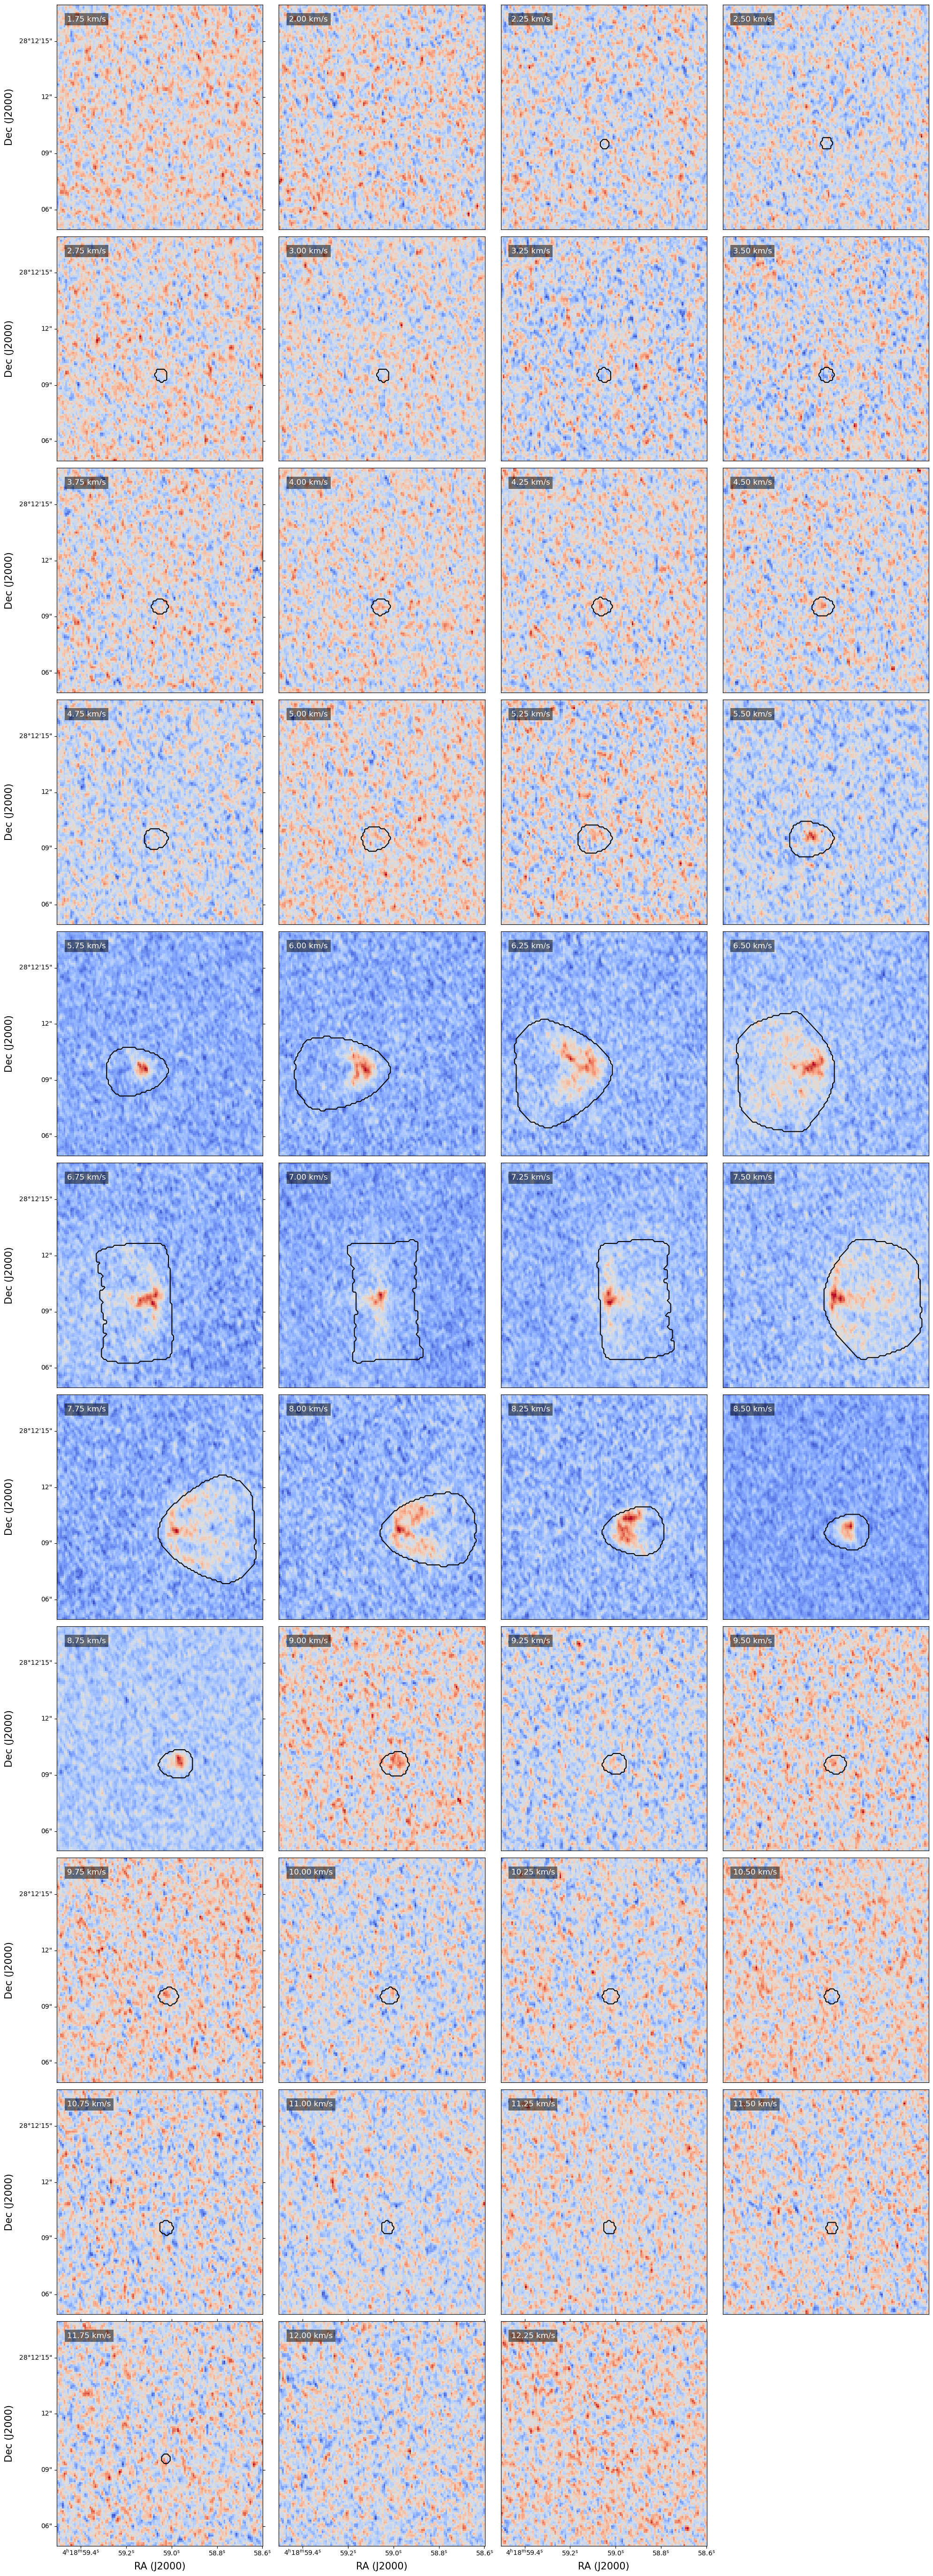

In [113]:
observed_cube = f'{line_dir}/{source}_{line}_clean.image'
observed_cube_fits = f'{line_dir}/{source}_{line}_clean.image.fits'
mask_cube = f'{mask_dir}/m{best_mstar:.3f}_1.5dust_r_0.3zr.conv.mask.image'

# Export CASA image to FITS if needed for WCS
exportfits(imagename=observed_cube, fitsimage=observed_cube_fits, overwrite=True, dropdeg=True)

# Finding pixel positions of the disk center
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.io import fits
import astropy.units as u

def dot_to_colon(sexagesimal_str):
    """Convert dot-separated sexagesimal to colon-separated string."""
    sign = ''
    if sexagesimal_str.startswith(('+', '-')):
        sign = sexagesimal_str[0]
        sexagesimal_str = sexagesimal_str[1:]
    
    parts = sexagesimal_str.split('.')
    if len(parts) == 4:
        # Combine last two parts for seconds
        new_parts = parts[:2] + [f"{parts[2]}.{parts[3]}"]
    elif len(parts) == 3:
        new_parts = parts
    else:
        raise ValueError("Input must have 3 or 4 parts: 'HH.MM.SS' or 'HH.MM.SS.sss'")
    
    return f"{sign}{':'.join(new_parts)}"

# Load WCS from FITS header
hdu = fits.open(observed_cube_fits)[0]
wcs = WCS(hdu.header)

# Define RA/Dec center (assumes you have them as strings or floats)
formatted_dec_center = dot_to_colon(dec_center)
coord = SkyCoord(ra_center, formatted_dec_center, unit=(u.hourangle, u.deg), frame='icrs')

# Convert SkyCoord RA/Dec to pixel coordinates, using frequency as the first axis
x_pix, y_pix = wcs.celestial.world_to_pixel(coord)

center_coords = (int(x_pix), int(y_pix))
print(f"Disk center pixel coordinates: {center_coords}")

# Call plotting function
plot_channel_maps_auto(
    observed_cube=observed_cube,
    rest_freq=restfreq,
    center_coords=center_coords,
    mask_cube=mask_cube,     # Provide mask if available
    mid_chan=None,           # No need for mid_chan if mask provided
    zoom_factor=3.0,
    chan_width_kms=0.25      # Channel width (optional if not default)
)

## Step 12: Generate Keplerian Masks for a Range of Gas Radii

In this step, we generate a suite of Keplerian masks to explore how far the gas disk extends beyond the dust disk.

- The gas disk radius (`r_max`) is varied from **1× to 3× the dust radius** in increments of **0.25×**.
- Each mask uses the **best-fit stellar mass** from Step 9 and the known disk geometry (inclination, PA, systemic velocity).
- A flared disk profile (`z/r = 0.3`) and resolution targeting (`0.3 arcsec`) are assumed.
- After generation, each mask is **recentered** to the actual disk center using the moment 0 map.
- These masks will be evaluated in a later step to identify the best-fit gas radius or average emission extent.

This step allows us to assess how gas disk size compares with the dust disk and prepares masks for visual and quantitative analysis.

In [114]:
r_factors = np.arange(1.0, 3.01, 0.5)  

for r_factor in r_factors:
    generate_mask(
        line_image=line_image,
        i=i,
        pa=pa,
        mstar=best_mstar,       
        dist_pc=dist_pc,
        vlsr=vlsr,
        dust_r=dust_r,
        mode='r',
        r_factor=r_factor)

# Estimated RMS of unmasked regions: 6.68 mJy/beam
# If there are strong sidelobes this may overestimate the RMS.
# Estimated RMS of unmasked regions: 6.68 mJy/beam
# If there are strong sidelobes this may overestimate the RMS.
# Estimated RMS of unmasked regions: 6.68 mJy/beam
# If there are strong sidelobes this may overestimate the RMS.
# Estimated RMS of unmasked regions: 6.68 mJy/beam
# If there are strong sidelobes this may overestimate the RMS.
# Estimated RMS of unmasked regions: 6.67 mJy/beam
# If there are strong sidelobes this may overestimate the RMS.


# Apply masks